In [1]:
import qiskit
from qiskit import QuantumCircuit, transpile

import sys
from pathlib import Path

sys.path.append('..')
from network_emulation import (
    NODE_NAMES, NUM_NODES, INITIAL_STATES, STATE_LABELS,
    CONNECTION_TUPLES, get_node_name, route_name, get_node_id,
    # Config loading
    load_nodes_config, load_routes_config,
    # Experiment execution
    initialize_backend,
)

In [2]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
# Set USE_REAL_HARDWARE = True to run on actual IBM quantum hardware
# Set USE_REAL_HARDWARE = False to use the FakeFez simulator
# ============================================================

USE_REAL_HARDWARE = False  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 0      # Transpiler optimization (0 = no optimization)

# Configuration file paths
CONFIG_DIR = Path('../configs')
NODES_FILE = CONFIG_DIR / 'config_1_nodes.json'
ROUTES_FILE = CONFIG_DIR / 'config_1_routes.json'
OUTPUT_DIR = Path('../outputs/syndromes')

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Initial states:     {[STATE_LABELS[s] for s in INITIAL_STATES]}")
print(f"\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")


# ============================================================
# LOAD CONFIGURATIONS
# ============================================================

# Load node and route configurations from JSON files
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {get_node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total)")
print(f"Connection pairs: {len(CONNECTION_TUPLES)}")


# ============================================================
# INITIALIZE BACKEND
# ============================================================

# Initialize quantum backend (FakeFez simulator or real IBM Fez)
backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(
    USE_REAL_HARDWARE,
    secrets_path='../secrets/keys.json',
    simulation_method="matrix_product_state"
)

EXPERIMENT CONFIGURATION
Hardware mode:      FakeFez SIMULATOR
Shots per circuit:  4096
Optimization level: 0
Initial states:     ['|0⟩', '|1⟩', '|+⟩', '|−⟩']

Config files:
  Nodes:  ../configs/config_1_nodes.json (exists: True)
  Routes: ../configs/config_1_routes.json (exists: True)
LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[76], encoding=[61, 81], ancilla=[62, 82]
  Node B: data=[77], encoding=[65, 85], ancilla=[66, 86]
  Node C: data=[78], encoding=[69, 89], ancilla=[70, 90]
  Node D: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node E: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node F: data=[98], encoding=[91, 111], ancilla=[92, 112]

Routes (30 total)
Connection pairs: 30
Loaded SIMULATOR backend: fake_fez
  Qubits: 156
  Simulation method: matrix_product_state


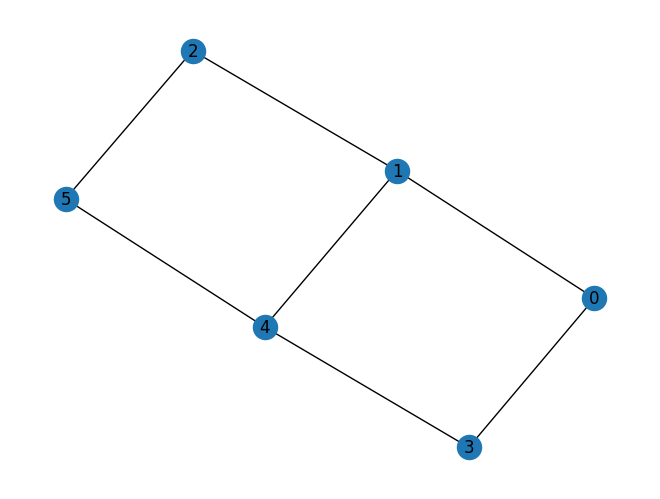

In [3]:
import networkx
from networkx import Graph
import pickle
# Load Graph pickle file

with open('../pickle_files/2x3_grid_network_graph.pkl', 'rb') as f:
    network_graph: Graph = pickle.load(f)

networkx.draw(network_graph, with_labels=True)

In [5]:
# Get all independent edges of the network graph
single_hop_edges = network_graph.edges()
list(single_hop_edges)

[(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]

# General Idea
Perform transform state to the X, Y, Z basis, accumulate the basis errors and then translate the PD of output states to their respective $$p_x, p_y, p_z$$ error values.  
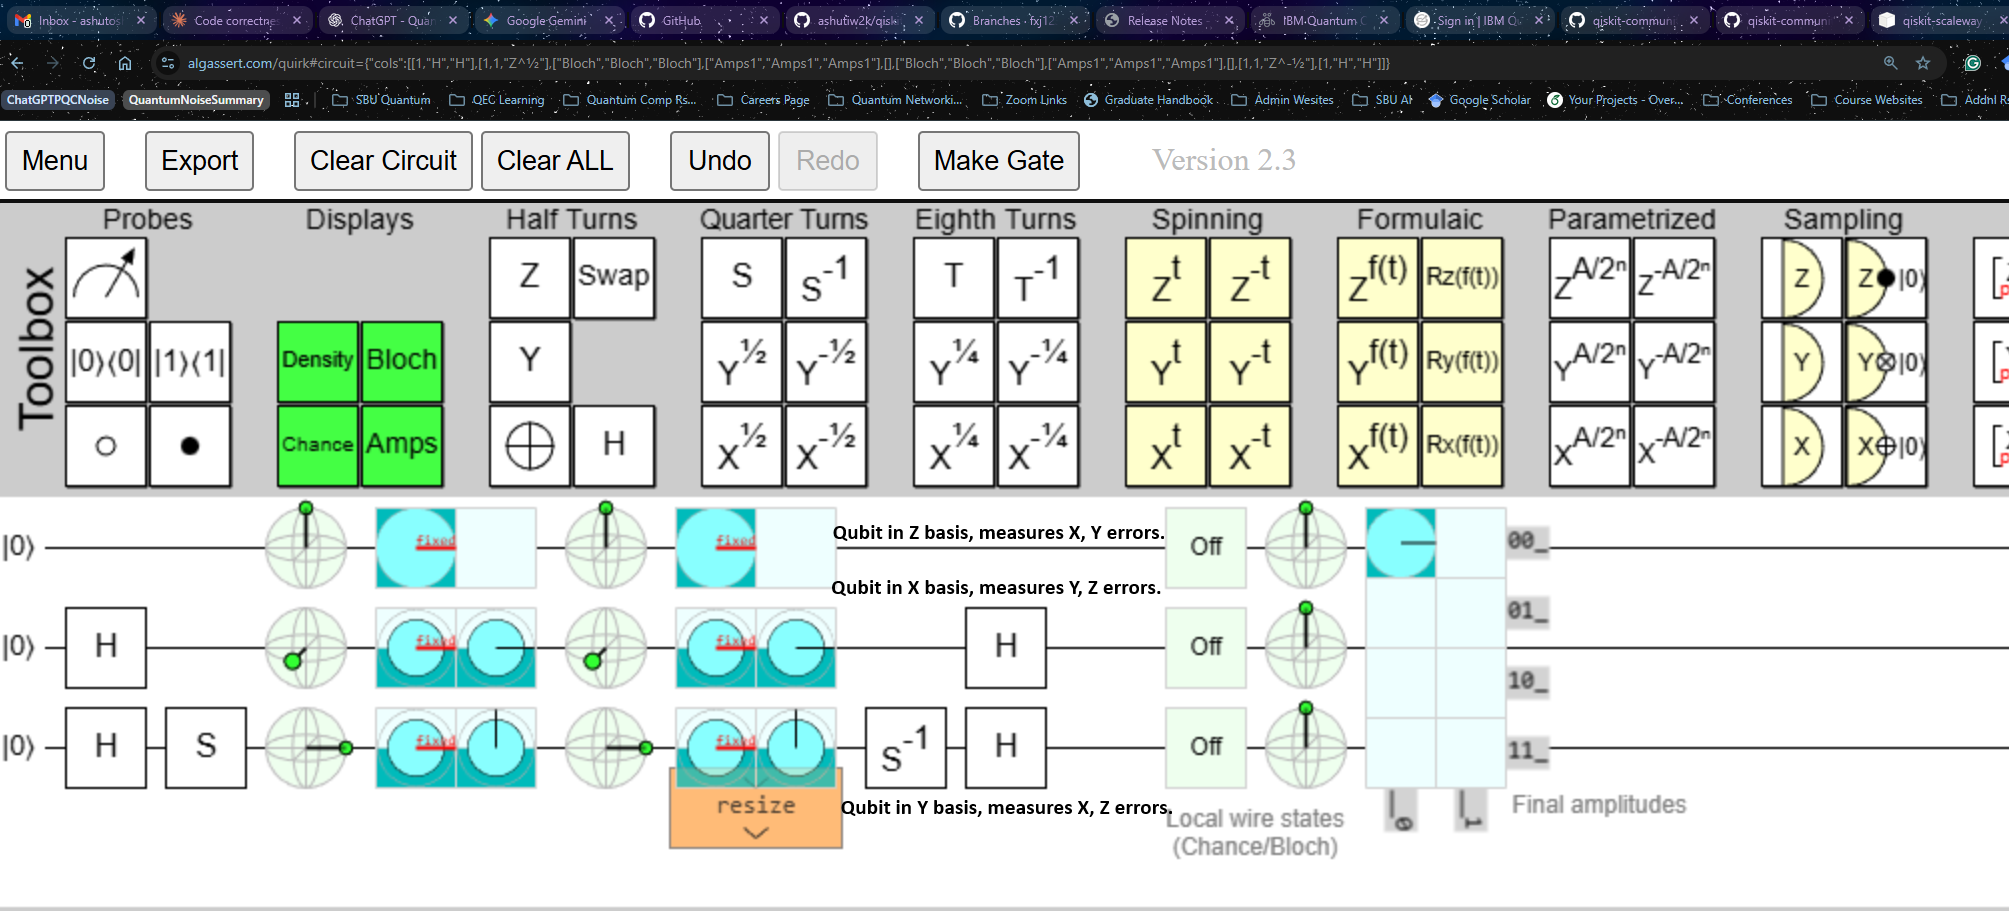

# CLAUDE CODE

In [ ]:
from qiskit import QuantumCircuit, ClassicalRegister
from typing import List, Dict, Tuple


def build_multihop_swapping_circuit(
    node_path: List[int],
    initial_state: str,
    nodes: Dict[int, dict],
    routes: Dict[Tuple[int, int], dict],
    num_qubits: int,
    measurement_basis: str = "Z",
) -> QuantumCircuit:
    """
    Build a multi-hop SWAP-transport circuit for quantum state tomography.
    
    This circuit:
    1. Prepares initial state in Z basis (|0⟩ or |1⟩)
    2. Encodes into [3,1,1] repetition code (|000⟩ or |111⟩)
    3. Rotates to measurement basis (so errors affect the state correctly)
    4. Transports qubits through multiple hops via SWAP operations
    5. Rotates back from measurement basis
    6. Measures in Z basis
    
    The key insight: Transport must happen in the BASIS where errors are detectable.
    - Z-basis transport: X errors flip bits, Z errors invisible
    - X-basis transport: Z errors flip states, X errors invisible
    - Y-basis transport: both X and Z errors visible
    
    For complete error characterization, run this function three times
    with measurement_basis="X", "Y", and "Z" to perform quantum state tomography.
    
    Args:
        node_path: Ordered list of node IDs describing the path (>=2 nodes).
        initial_state: "0" or "1" (prepared on the source node's data qubit).
        nodes: Dict mapping node_id -> {"data": int, "encoding": [int,int], ...}
        routes: Dict mapping (src_node,dst_node) -> {"movements": [[path1],[path2],[path3]]}
                where each path is a list of physical qubit indices to SWAP along.
        num_qubits: Total number of physical qubits in the backend.
        measurement_basis: One of {"X", "Y", "Z"} selecting the measurement basis.
                          "Z" -> transport in Z basis, measure Z (detects X and Y errors)
                          "X" -> transport in X basis, measure X (detects Z and Y errors)
                          "Y" -> transport in Y basis, measure Y (detects X and Z errors)
    
    Returns:
        QuantumCircuit with ClassicalRegister "meas_<basis>_<finalnode>"
        
    Usage Example:
        # For complete tomography, run three times:
        circuit_z = build_multihop_swapping_circuit(..., measurement_basis="Z")
        circuit_x = build_multihop_swapping_circuit(..., measurement_basis="X")
        circuit_y = build_multihop_swapping_circuit(..., measurement_basis="Y")
        
        # Execute each circuit independently and collect counts
        # Then use calculate_exact_pauli_rates() to get error rates
    """
    # Input validation
    if len(node_path) < 2:
        raise ValueError("node_path must contain at least 2 nodes")
    if initial_state not in ("0", "1"):
        raise ValueError("initial_state must be '0' or '1'")
    if measurement_basis not in ("X", "Y", "Z"):
        raise ValueError("measurement_basis must be one of ('X', 'Y', 'Z')")

    start_node = node_path[0]
    final_node = node_path[-1]
    circuit = QuantumCircuit(num_qubits)

    # ========================================================================
    # PHASE 1: Prepare initial state in Z basis
    # ========================================================================
    src_data = nodes[start_node]["data"]
    if initial_state == "1":
        circuit.x(src_data)
    
    circuit.barrier(label=f"Init: |{initial_state}⟩ @ {get_node_name(start_node)}")

    # ========================================================================
    # PHASE 2: Encode into [3,1,1] repetition code
    # ========================================================================
    # |0⟩ → |000⟩ or |1⟩ → |111⟩
    src_encoding = nodes[start_node]["encoding"]
    for enc_q in src_encoding:
        circuit.cx(src_data, enc_q)
    
    logical_src = [src_data] + list(src_encoding)
    circuit.barrier(label=f"Encode: |{initial_state*3}⟩")

    # ========================================================================
    # PHASE 3: Rotate to measurement basis (BEFORE transport)
    # ========================================================================
    # This is critical! We rotate BEFORE transport so that errors during
    # transport affect the state in a measurable way.
    circuit.barrier(label=f"Rotate to {measurement_basis} basis")
    
    for q in logical_src:
        if measurement_basis == "X":
            # Z → X: |0⟩ → |+⟩, |1⟩ → |-⟩
            circuit.h(q)
        elif measurement_basis == "Y":
            # Z → Y: |0⟩ → |+i⟩, |1⟩ → |-i⟩
            # Correct rotation: H then S
            circuit.h(q)
            circuit.s(q)
        # Z basis needs no rotation

    # ========================================================================
    # PHASE 4: Multi-hop transport via SWAP operations
    # ========================================================================
    # Transport happens in the ROTATED basis
    # - If measurement_basis="X": transport |+++⟩ or |---⟩, Z errors flip states
    # - If measurement_basis="Y": transport |+i,+i,+i⟩ or |-i,-i,-i⟩
    # - If measurement_basis="Z": transport |000⟩ or |111⟩, X errors flip bits
    for hop_idx in range(len(node_path) - 1):
        src_node = node_path[hop_idx]
        dst_node = node_path[hop_idx + 1]

        if (src_node, dst_node) not in routes:
            raise KeyError(f"Missing route for hop {(src_node, dst_node)}")

        route = routes[(src_node, dst_node)]["movements"]
        swapping_sequence = [list(zip(path, path[1:])) for path in route]

        circuit.barrier(label=f"Hop {hop_idx+1}: {get_node_name(src_node)}→{get_node_name(dst_node)}")
        
        for path_swaps in swapping_sequence:
            for q1, q2 in path_swaps:
                circuit.swap(q1, q2)

    # ========================================================================
    # PHASE 5: Rotate back from measurement basis to Z basis
    # ========================================================================
    dst_data = nodes[final_node]["data"]
    dst_encoding = nodes[final_node]["encoding"]
    logical_dst = [dst_data] + list(dst_encoding)

    circuit.barrier(label=f"Rotate back from {measurement_basis} basis")
    
    for q in logical_dst:
        if measurement_basis == "X":
            # X → Z: inverse of H is H
            circuit.h(q)
        elif measurement_basis == "Y":
            # Y → Z: inverse of H·S is S†·H
            circuit.sdg(q)
            circuit.h(q)
        # Z basis needs no rotation

    # ========================================================================
    # PHASE 6: Measure all qubits in Z basis
    # ========================================================================
    circuit.barrier(label=f"Measure @ {get_node_name(final_node)}")
    
    creg = ClassicalRegister(len(logical_dst), name=f"meas_{measurement_basis}_{final_node}")
    circuit.add_register(creg)

    for i, q in enumerate(logical_dst):
        circuit.measure(q, creg[i])

    return circuit


# ============================================================================
# Helper function for visualization (assumes this exists in your codebase)
# ============================================================================
def get_node_name(node_id: int) -> str:
    """
    Convert node ID to human-readable name.
    This is a placeholder - replace with your actual implementation.
    """
    return f"Node{node_id}"


# ============================================================================
# Example usage
# ============================================================================
if __name__ == "__main__":
    # Example node and route configuration
    nodes = {
        0: {"data": 0, "encoding": [1, 2]},
        1: {"data": 3, "encoding": [4, 5]},
        2: {"data": 6, "encoding": [7, 8]},
    }
    
    routes = {
        (0, 1): {
            "movements": [
                [0, 3],      # Path for qubit 0 (data)
                [1, 4],      # Path for qubit 1 (encoding[0])
                [2, 5],      # Path for qubit 2 (encoding[1])
            ]
        },
        (1, 2): {
            "movements": [
                [3, 6],      # Path for qubit 3 → 6
                [4, 7],      # Path for qubit 4 → 7
                [5, 8],      # Path for qubit 5 → 8
            ]
        },
    }
    
    node_path = [0, 1, 2]
    num_qubits = 9
    
    # Generate circuits for complete tomography
    circuit_z = build_multihop_swapping_circuit(
        node_path=node_path,
        initial_state="0",
        nodes=nodes,
        routes=routes,
        num_qubits=num_qubits,
        measurement_basis="Z"
    )
    
    circuit_x = build_multihop_swapping_circuit(
        node_path=node_path,
        initial_state="0",
        nodes=nodes,
        routes=routes,
        num_qubits=num_qubits,
        measurement_basis="X"
    )
    
    circuit_y = build_multihop_swapping_circuit(
        node_path=node_path,
        initial_state="0",
        nodes=nodes,
        routes=routes,
        num_qubits=num_qubits,
        measurement_basis="Y"
    )
    
    print("Z-basis circuit depth:", circuit_z.depth())
    print("X-basis circuit depth:", circuit_x.depth())
    print("Y-basis circuit depth:", circuit_y.depth())
    
    # After running on quantum hardware:
    # z_counts = execute(circuit_z, backend).result().get_counts()
    # x_counts = execute(circuit_x, backend).result().get_counts()
    # y_counts = execute(circuit_y, backend).result().get_counts()
    #
    # Then use calculate_exact_pauli_rates(z_counts, x_counts, y_counts)

In [ ]:
import numpy as np
from typing import Dict


def calculate_exact_pauli_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '000'
) -> Dict[str, float]:
    """
    Calculate exact X, Y, and Z error rates using full quantum state tomography.
    
    Requires three independent measurement runs in different bases to solve
    the system of equations for Pauli error probabilities.
    
    Theory:
        - Z-basis measurement detects: E_z = P(X) + P(Y)
        - X-basis measurement detects: E_x = P(Z) + P(Y)
        - Y-basis measurement detects: E_y = P(X) + P(Z)
    
    Solving this system:
        P(X) = (E_z + E_y - E_x) / 2
        P(Y) = (E_z + E_x - E_y) / 2
        P(Z) = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: Measurement counts from Z-basis run (detects X and Y errors)
                       e.g., {'000': 850, '100': 50, '010': 30, ...}
        x_basis_counts: Measurement counts from X-basis run (detects Z and Y errors)
                       e.g., {'000': 820, '100': 60, '001': 40, ...}
        y_basis_counts: Measurement counts from Y-basis run (detects X and Z errors)
                       e.g., {'000': 800, '100': 70, '010': 45, ...}
        expected_state: Expected outcome without errors ('000' or '111')
    
    Returns:
        Dictionary with exact error rates:
        {
            'PX': float,  # X error probability
            'PY': float,  # Y error probability
            'PZ': float,  # Z error probability
            'E_z': float, # Raw Z-basis error rate
            'E_x': float, # Raw X-basis error rate
            'E_y': float, # Raw Y-basis error rate
            'total_shots': dict
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        """Calculate the total error rate for a measurement basis."""
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    # Calculate observed error rates in each basis
    E_z = get_error_rate(z_basis_counts, expected_state)  # P(X) + P(Y)
    E_x = get_error_rate(x_basis_counts, expected_state)  # P(Z) + P(Y)
    E_y = get_error_rate(y_basis_counts, expected_state)  # P(X) + P(Z)
    
    # Solve the system of linear equations
    px = 0.5 * (E_z + E_y - E_x)
    py = 0.5 * (E_z + E_x - E_y)
    pz = 0.5 * (E_x + E_y - E_z)
    
    # Clean up small negatives due to statistical noise
    return {
        'PX': max(0.0, px),
        'PY': max(0.0, py),
        'PZ': max(0.0, pz),
        'E_z': E_z,
        'E_x': E_x,
        'E_y': E_y,
        'total_shots': {
            'z_basis': sum(z_basis_counts.values()),
            'x_basis': sum(x_basis_counts.values()),
            'y_basis': sum(y_basis_counts.values())
        }
    }


def calculate_per_qubit_pauli_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '000',
    num_qubits: int = 3
) -> Dict[str, np.ndarray]:
    """
    Calculate error rates for each individual qubit position.
    
    This provides more detailed analysis by tracking which qubits
    in the [3,1,1] repetition code are most susceptible to errors.
    
    Args:
        z_basis_counts: Z-basis measurement counts
        x_basis_counts: X-basis measurement counts
        y_basis_counts: Y-basis measurement counts
        expected_state: Expected outcome ('000' or '111')
        num_qubits: Number of qubits (default 3)
    
    Returns:
        Dictionary with per-qubit error rates:
        {
            'PX_per_qubit': array of X error rates,
            'PY_per_qubit': array of Y error rates,
            'PZ_per_qubit': array of Z error rates
        }
    """
    
    def count_flips_per_qubit(counts: Dict[str, int], expected: str) -> np.ndarray:
        """Count bit flips at each qubit position."""
        total_shots = sum(counts.values())
        flips = np.zeros(num_qubits)
        
        for outcome, count in counts.items():
            for i, (measured_bit, expected_bit) in enumerate(zip(outcome, expected)):
                if measured_bit != expected_bit:
                    flips[i] += count
        
        return flips / total_shots if total_shots > 0 else flips
    
    # Get flip rates per qubit for each basis
    E_z_per_qubit = count_flips_per_qubit(z_basis_counts, expected_state)
    E_x_per_qubit = count_flips_per_qubit(x_basis_counts, expected_state)
    E_y_per_qubit = count_flips_per_qubit(y_basis_counts, expected_state)
    
    # Solve for each qubit independently
    px_per_qubit = 0.5 * (E_z_per_qubit + E_y_per_qubit - E_x_per_qubit)
    py_per_qubit = 0.5 * (E_z_per_qubit + E_x_per_qubit - E_y_per_qubit)
    pz_per_qubit = 0.5 * (E_x_per_qubit + E_y_per_qubit - E_z_per_qubit)
    
    return {
        'PX_per_qubit': np.maximum(0.0, px_per_qubit),
        'PY_per_qubit': np.maximum(0.0, py_per_qubit),
        'PZ_per_qubit': np.maximum(0.0, pz_per_qubit),
        'E_z_per_qubit': E_z_per_qubit,
        'E_x_per_qubit': E_x_per_qubit,
        'E_y_per_qubit': E_y_per_qubit
    }


# Example usage
if __name__ == "__main__":
    # Simulated measurement results from three independent runs
    z_basis_counts = {
        '000': 850,
        '100': 30,
        '010': 25,
        '001': 20,
        '110': 15,
        '111': 10,
    }
    
    x_basis_counts = {
        '000': 820,
        '100': 35,
        '010': 30,
        '001': 25,
        '110': 20,
        '111': 15,
    }
    
    y_basis_counts = {
        '000': 830,
        '100': 32,
        '010': 28,
        '001': 22,
        '110': 18,
        '111': 12,
    }
    
    expected_state = '000'
    
    # Calculate aggregate error rates
    results = calculate_exact_pauli_rates(
        z_basis_counts, 
        x_basis_counts, 
        y_basis_counts, 
        expected_state
    )
    
    print("Aggregate Error Rates:")
    print(f"P(X) = {results['PX']:.4f}")
    print(f"P(Y) = {results['PY']:.4f}")
    print(f"P(Z) = {results['PZ']:.4f}")
    print(f"\nObserved rates:")
    print(f"E_z (Z-basis) = {results['E_z']:.4f}")
    print(f"E_x (X-basis) = {results['E_x']:.4f}")
    print(f"E_y (Y-basis) = {results['E_y']:.4f}")
    
    # Calculate per-qubit error rates
    per_qubit = calculate_per_qubit_pauli_rates(
        z_basis_counts,
        x_basis_counts,
        y_basis_counts,
        expected_state
    )
    
    print("\nPer-Qubit Error Rates:")
    for i in range(3):
        print(f"Qubit {i}: PX={per_qubit['PX_per_qubit'][i]:.4f}, "
              f"PY={per_qubit['PY_per_qubit'][i]:.4f}, "
              f"PZ={per_qubit['PZ_per_qubit'][i]:.4f}")

In [ ]:
edge_error_values = {}
for edge in single_hop_edges: